# Quick start

This notebook demonstrates how to use `pyCRO` in the simplest configuration of the Recharge Oscillator (RO) model, featuring linear dynamics and additive white-noise forcing.

The RO model is written as:

$\displaystyle \frac{dT}{dt} = RT + F_{1}h + \sigma_{T}w_{T}$

$\displaystyle \frac{dh}{dt} = -\varepsilon h - F_{2}T + \sigma_{h}w_{h}$

where:

- $T$ is the sea surface temperature (SST) anomaly,
- $h$ is the upper-ocean heat content (recharge state),
- $w_T$ and $w_h$ are independent white-noise processes,
- $R$, $F_1$, $F_2$, and $\varepsilon$ are dynamical RO feedback parameters,
- $\sigma_T$ and $\sigma_h$ control stochastic forcing amplitudes.

This notebook was contributed by [Sen Zhao](https://senzhao.netlify.app/).


In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys

import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("../../../"))

import pyCRO

## Load precomputed RO parameters from ORAS5

In [2]:
par = pyCRO.par_load(data_name="ORAS5", ro_name = "Linear-White-Additive")
par

{'R': [-0.0731702636710546],
 'F1': [0.017938268057197594],
 'F2': [1.2939079422481348],
 'epsilon': [0.008754185790444461],
 'b_T': [],
 'c_T': [],
 'd_T': [],
 'b_h': [],
 'sigma_T': [0.21698921132838628],
 'sigma_h': [1.5547824185851542],
 'B': [],
 'm_T': [],
 'm_h': [],
 'n_T': [1],
 'n_h': [1],
 'n_g': [2]}

## Conduct RO simulations

In [3]:
IC = [1.0, 0.0]              # Initial conditions for T and h
N = 12 * 100                 # Simulation length in months (e.g., 100 years)
NE = 2                       # Number of ensemble members

RO_ds = pyCRO.CRO_simulate(par, IC, N, NE, verbose=False)
RO_ds

<xarray.Dataset> Size: 48kB
Dimensions:  (time: 1200, member: 2)
Coordinates:
  * time     (time) datetime64[ns] 10kB 1900-01-01 1900-02-01 ... 1999-12-01
  * member   (member) int64 16B 0 1
Data variables:
    T        (time, member) float64 19kB 1.0 1.0 0.4566 ... -1.924 0.8034 -2.128
    h        (time, member) float64 19kB 0.0 0.0 -2.964 ... -13.88 12.26 -12.31

## Plot the outputs

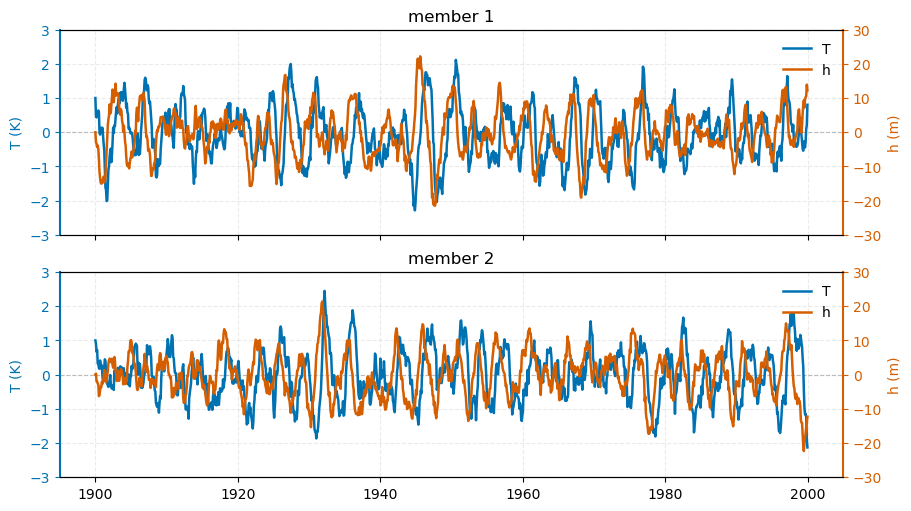

In [6]:
time_axis = RO_ds.time

n_row = 2
fig, axes = plt.subplots(
    n_row, 1,
    figsize=(9, 5),
    sharex=True,
    sharey=True,
    layout='constrained'
)

color_T = "#0072B2"   # Nature-style blue (Okabe-Ito)
color_h = "#D55E00"   # Nature-style vermillion/orange

for i, ax in enumerate(axes.flat):

    # --- T (left axis) ---
    line1, = ax.plot(time_axis, RO_ds['T'][:, i],
                     color=color_T, lw=1.8, label="T")

    ax.set_ylabel("T (K)", color=color_T)
    ax.tick_params(axis='y', colors=color_T)

    ax.spines['left'].set_color(color_T)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['right'].set_visible(False)

    # zero line
    ax.axhline(0, ls='--', c='gray', lw=0.8, alpha=0.5, zorder=0)

    # --- h (right axis) ---
    axR = ax.twinx()
    line2, = axR.plot(time_axis, RO_ds['h'][:, i],
                      color=color_h, lw=1.8, label="h")

    axR.set_ylabel("h (m)", color=color_h)
    axR.tick_params(axis='y', colors=color_h)

    axR.spines['right'].set_color(color_h)
    axR.spines['right'].set_linewidth(1.5)
    axR.spines['left'].set_visible(False)

    axR.set_ylim([-30, 30])
    ax.set_ylim([-3, 3])

    # --- combined legend (clean) ---
    ax.legend(handles=[line1, line2], loc="upper right", frameon=False)
    ax.set_title(f"member {i+1}")

# shared x-axis styling
# axes[-1].set_xlabel("Time (months)")

for ax in axes:
    ax.grid(True, alpha=0.25, linestyle='--')

plt.show()